# 21 — Valoração por Cenários Econômicos

## Objetivo

Valorar monetariamente as políticas candidatas usando:

- resultados já auditados no notebook `20_Explicabilidade_E_Politica_Final.ipynb`;
- cenários econômicos documentados em `docs/PREMISSAS_ECONOMICAS_EXTERNAS.md`;
- matriz de decisão baseada em `TP`, `FP`, `FN` e `TN`.

Este notebook é intencionalmente leve: ele não reconstrói a base, não retreina modelos e não recalcula
probabilidades. O foco é aplicar a função econômica aos resultados já gerados.

## Limites

- os valores são simulação de cenário, não ROI real;
- os custos não são dados internos da Vale;
- `Is_Dont_Go` não é falha confirmada;
- `Manutenção` é proxy operacional, não causalidade;
- escavadeiras continuam sem recomendação operacional com este target.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)

## 1. Premissas Econômicas

In [2]:
economic_scenarios = pd.DataFrame([
    {
        "cenario": "conservador",
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.40,
        "custo_intervencao_preditiva": 15000.0,
        "custo_manutencao_corretiva": 40000.0,
        "impacto_operacional_hora": 15000.0,
        "horas_parada_preditiva": 1.0,
        "horas_parada_corretiva": 3.0,
    },
    {
        "cenario": "base",
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.655,
        "custo_intervencao_preditiva": 10000.0,
        "custo_manutencao_corretiva": 50000.0,
        "impacto_operacional_hora": 30000.0,
        "horas_parada_preditiva": 1.0,
        "horas_parada_corretiva": 4.0,
    },
    {
        "cenario": "agressivo",
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.75,
        "custo_intervencao_preditiva": 10000.0,
        "custo_manutencao_corretiva": 80000.0,
        "impacto_operacional_hora": 45000.0,
        "horas_parada_preditiva": 1.0,
        "horas_parada_corretiva": 6.0,
    },
    {
        "cenario": "conservador",
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.20,
        "custo_intervencao_preditiva": 35000.0,
        "custo_manutencao_corretiva": 100000.0,
        "impacto_operacional_hora": 60000.0,
        "horas_parada_preditiva": 2.0,
        "horas_parada_corretiva": 6.0,
    },
    {
        "cenario": "base",
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.20,
        "custo_intervencao_preditiva": 25000.0,
        "custo_manutencao_corretiva": 150000.0,
        "impacto_operacional_hora": 100000.0,
        "horas_parada_preditiva": 2.0,
        "horas_parada_corretiva": 8.0,
    },
    {
        "cenario": "agressivo",
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.40,
        "custo_intervencao_preditiva": 25000.0,
        "custo_manutencao_corretiva": 250000.0,
        "impacto_operacional_hora": 150000.0,
        "horas_parada_preditiva": 2.0,
        "horas_parada_corretiva": 12.0,
    },
])

economic_scenarios["valor_tp_unitario"] = economic_scenarios["p_acao_confirmada"] * (
    economic_scenarios["custo_manutencao_corretiva"]
    + economic_scenarios["impacto_operacional_hora"] * economic_scenarios["horas_parada_corretiva"]
) - (
    economic_scenarios["custo_intervencao_preditiva"]
    + economic_scenarios["p_acao_confirmada"]
    * economic_scenarios["impacto_operacional_hora"]
    * economic_scenarios["horas_parada_preditiva"]
)
economic_scenarios["valor_fp_unitario"] = -(
    economic_scenarios["custo_intervencao_preditiva"]
    + economic_scenarios["impacto_operacional_hora"]
    * economic_scenarios["horas_parada_preditiva"]
)
display(economic_scenarios)

,cenario,Tipo,p_acao_confirmada,custo_intervencao_preditiva,custo_manutencao_corretiva,impacto_operacional_hora,horas_parada_preditiva,horas_parada_corretiva,valor_tp_unitario,valor_fp_unitario
0,conservador,Caminhao,0.400,15000.0,40000.0,15000.0,1.0,3.0,13000.0,-30000.0
1,base,Caminhao,0.655,10000.0,50000.0,30000.0,1.0,4.0,81700.0,-40000.0
2,agressivo,Caminhao,0.750,10000.0,80000.0,45000.0,1.0,6.0,218750.0,-55000.0
3,conservador,Escavadeira,0.200,35000.0,100000.0,60000.0,2.0,6.0,33000.0,-155000.0
4,base,Escavadeira,0.200,25000.0,150000.0,100000.0,2.0,8.0,125000.0,-225000.0
5,agressivo,Escavadeira,0.400,25000.0,250000.0,150000.0,2.0,12.0,675000.0,-325000.0


## 2. Resultados Auditados do Notebook 20

In [3]:
# Resultados do notebook 20 usando faixas robustas ou thresholds candidatos finais.
# Valores por split no teste. Escavadeiras nos modelos mistos tiveram 0 TP e 0 FP nos candidatos finais.
policy_counts = pd.DataFrame([
    # CatBoost caminhão-only, threshold robusto 0,390-0,440
    {"politica": "caminhoes_catboost_multijanela", "modelo": "CatBoost", "escopo": "Caminhoes", "split": "S1_abril", "Tipo": "Caminhao", "TP": 88, "FP": 99, "FN": 275, "TN": np.nan, "threshold_ref": "0,390-0,440"},
    {"politica": "caminhoes_catboost_multijanela", "modelo": "CatBoost", "escopo": "Caminhoes", "split": "S2_maio", "Tipo": "Caminhao", "TP": 67, "FP": 76, "FN": 213, "TN": np.nan, "threshold_ref": "0,390-0,440"},
    {"politica": "caminhoes_catboost_multijanela", "modelo": "CatBoost", "escopo": "Caminhoes", "split": "S3_junho", "Tipo": "Caminhao", "TP": 63, "FP": 46, "FN": 220, "TN": np.nan, "threshold_ref": "0,390-0,440"},

    # CatBoost misto, threshold robusto 0,420-0,480
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S1_abril", "Tipo": "Caminhao", "TP": 87, "FP": 94, "FN": 276, "TN": np.nan, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S1_abril", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 1, "TN": np.nan, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S2_maio", "Tipo": "Caminhao", "TP": 58, "FP": 75, "FN": 222, "TN": np.nan, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S2_maio", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 7, "TN": np.nan, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S3_junho", "Tipo": "Caminhao", "TP": 56, "FP": 33, "FN": 227, "TN": np.nan, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S3_junho", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 2, "TN": np.nan, "threshold_ref": "0,420-0,480"},

    # RandomForest referência caminhão-only, threshold robusto 0,380-0,390
    {"politica": "caminhoes_rf_referencia", "modelo": "RandomForest", "escopo": "Caminhoes", "split": "S1_abril", "Tipo": "Caminhao", "TP": 96, "FP": 120, "FN": 267, "TN": np.nan, "threshold_ref": "0,380-0,390"},
    {"politica": "caminhoes_rf_referencia", "modelo": "RandomForest", "escopo": "Caminhoes", "split": "S2_maio", "Tipo": "Caminhao", "TP": 70, "FP": 103, "FN": 210, "TN": np.nan, "threshold_ref": "0,380-0,390"},
    {"politica": "caminhoes_rf_referencia", "modelo": "RandomForest", "escopo": "Caminhoes", "split": "S3_junho", "Tipo": "Caminhao", "TP": 50, "FP": 49, "FN": 233, "TN": np.nan, "threshold_ref": "0,380-0,390"},

    # RandomForest referência misto, threshold robusto 0,395-0,450
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S1_abril", "Tipo": "Caminhao", "TP": 95, "FP": 110, "FN": 268, "TN": np.nan, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S1_abril", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 1, "TN": np.nan, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S2_maio", "Tipo": "Caminhao", "TP": 62, "FP": 82, "FN": 218, "TN": np.nan, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S2_maio", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 7, "TN": np.nan, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S3_junho", "Tipo": "Caminhao", "TP": 45, "FP": 46, "FN": 238, "TN": np.nan, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S3_junho", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 2, "TN": np.nan, "threshold_ref": "0,395-0,450"},

    # XGBoost caminhão-only como sensibilidade, threshold escolhido na validação no notebook 20
    {"politica": "caminhoes_xgboost_multijanela_validacao", "modelo": "XGBoost", "escopo": "Caminhoes", "split": "S1_abril", "Tipo": "Caminhao", "TP": 117, "FP": 254, "FN": 246, "TN": np.nan, "threshold_ref": "validacao"},
    {"politica": "caminhoes_xgboost_multijanela_validacao", "modelo": "XGBoost", "escopo": "Caminhoes", "split": "S2_maio", "Tipo": "Caminhao", "TP": 76, "FP": 114, "FN": 204, "TN": np.nan, "threshold_ref": "validacao"},
    {"politica": "caminhoes_xgboost_multijanela_validacao", "modelo": "XGBoost", "escopo": "Caminhoes", "split": "S3_junho", "Tipo": "Caminhao", "TP": 98, "FP": 111, "FN": 185, "TN": np.nan, "threshold_ref": "validacao"},
])

policy_counts["positivos"] = policy_counts["TP"] + policy_counts["FN"]
policy_counts["predicoes_positivas"] = policy_counts["TP"] + policy_counts["FP"]
policy_counts["precision"] = policy_counts["TP"] / policy_counts["predicoes_positivas"].replace(0, np.nan)
policy_counts["recall"] = policy_counts["TP"] / policy_counts["positivos"].replace(0, np.nan)
display(policy_counts)

,politica,modelo,escopo,split,Tipo,TP,FP,FN,TN,threshold_ref,positivos,predicoes_positivas,precision,recall
0,caminhoes_catboost_multijanela,CatBoost,Caminhoes,S1_abril,Caminhao,88,99,275,NaN,"0,390-0,440",363,187,0.470588,0.242424
1,caminhoes_catboost_multijanela,CatBoost,Caminhoes,S2_maio,Caminhao,67,76,213,NaN,"0,390-0,440",280,143,0.468531,0.239286
2,caminhoes_catboost_multijanela,CatBoost,Caminhoes,S3_junho,Caminhao,63,46,220,NaN,"0,390-0,440",283,109,0.577982,0.222615
3,misto_catboost_multijanela,CatBoost,Misto,S1_abril,Caminhao,87,94,276,NaN,"0,420-0,480",363,181,0.480663,0.239669
4,misto_catboost_multijanela,CatBoost,Misto,S1_abril,Escavadeira,0,0,1,NaN,"0,420-0,480",1,0,NaN,0.000000
5,misto_catboost_multijanela,CatBoost,Misto,S2_maio,Caminhao,58,75,222,NaN,"0,420-0,480",280,133,0.436090,0.207143
6,misto_catboost_multijanela,CatBoost,Misto,S2_maio,Escavadeira,0,0,7,NaN,"0,420-0,480",7,0,NaN,0.000000
7,misto_catboost_multijanela,CatBoost,Misto,S3_junho,Caminhao,56,33,227,NaN,"0,420-0,480",283,89,0.629213,0.197880
8,misto_catboost_multijanela,CatBoost,Misto,S3_junho,Escavadeira,0,0,2,NaN,"0,420-0,480",2,0,NaN,0.000000
9,caminhoes_rf_referencia,RandomForest,Caminhoes,S1_abril,Caminhao,96,120,267,NaN,"0,380-0,390",363,216,0.444444,0.264463


## 3. Função de Valoração

In [4]:
def value_policy(counts, scenarios):
    rows = []
    for _, count in counts.iterrows():
        for _, scenario in scenarios[scenarios["Tipo"] == count["Tipo"]].iterrows():
            rows.append({
                **count.to_dict(),
                "cenario": scenario["cenario"],
                "valor_tp_unitario": scenario["valor_tp_unitario"],
                "valor_fp_unitario": scenario["valor_fp_unitario"],
                "valor_tp_total": count["TP"] * scenario["valor_tp_unitario"],
                "valor_fp_total": count["FP"] * scenario["valor_fp_unitario"],
                "valor_incremental": count["TP"] * scenario["valor_tp_unitario"] + count["FP"] * scenario["valor_fp_unitario"],
            })
    return pd.DataFrame(rows)

valuation = value_policy(policy_counts, economic_scenarios)
display(valuation[[
    "cenario", "politica", "split", "Tipo", "TP", "FP", "FN",
    "valor_tp_unitario", "valor_fp_unitario", "valor_tp_total",
    "valor_fp_total", "valor_incremental",
]])

,cenario,politica,split,Tipo,TP,FP,FN,valor_tp_unitario,valor_fp_unitario,valor_tp_total,valor_fp_total,valor_incremental
0,conservador,caminhoes_catboost_multijanela,S1_abril,Caminhao,88,99,275,13000.0,-30000.0,1144000.0,-2970000.0,-1826000.0
1,base,caminhoes_catboost_multijanela,S1_abril,Caminhao,88,99,275,81700.0,-40000.0,7189600.0,-3960000.0,3229600.0
2,agressivo,caminhoes_catboost_multijanela,S1_abril,Caminhao,88,99,275,218750.0,-55000.0,19250000.0,-5445000.0,13805000.0
3,conservador,caminhoes_catboost_multijanela,S2_maio,Caminhao,67,76,213,13000.0,-30000.0,871000.0,-2280000.0,-1409000.0
4,base,caminhoes_catboost_multijanela,S2_maio,Caminhao,67,76,213,81700.0,-40000.0,5473900.0,-3040000.0,2433900.0
5,agressivo,caminhoes_catboost_multijanela,S2_maio,Caminhao,67,76,213,218750.0,-55000.0,14656250.0,-4180000.0,10476250.0
6,conservador,caminhoes_catboost_multijanela,S3_junho,Caminhao,63,46,220,13000.0,-30000.0,819000.0,-1380000.0,-561000.0
7,base,caminhoes_catboost_multijanela,S3_junho,Caminhao,63,46,220,81700.0,-40000.0,5147100.0,-1840000.0,3307100.0
8,agressivo,caminhoes_catboost_multijanela,S3_junho,Caminhao,63,46,220,218750.0,-55000.0,13781250.0,-2530000.0,11251250.0
9,conservador,misto_catboost_multijanela,S1_abril,Caminhao,87,94,276,13000.0,-30000.0,1131000.0,-2820000.0,-1689000.0


## 4. Resultado por Política e Cenário

In [5]:
valuation_summary = (
    valuation.groupby(["cenario", "politica", "modelo", "escopo", "threshold_ref"])
    .agg(
        splits=("split", "nunique"),
        valor_medio=("valor_incremental", "mean"),
        valor_min=("valor_incremental", "min"),
        valor_max=("valor_incremental", "max"),
        valor_total_3_splits=("valor_incremental", "sum"),
        tp_medio=("TP", "mean"),
        fp_medio=("FP", "mean"),
        fn_medio=("FN", "mean"),
        precision_media=("precision", "mean"),
        recall_media=("recall", "mean"),
    )
    .reset_index()
    .sort_values(["cenario", "valor_medio"], ascending=[True, False])
)
display(valuation_summary)

print("Ranking por cenário:")
display(valuation_summary.groupby("cenario").head(10))

,cenario,politica,modelo,escopo,threshold_ref,splits,valor_medio,valor_min,valor_max,valor_total_3_splits,tp_medio,fp_medio,fn_medio,precision_media,recall_media
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.243708e+07,10355000.0,15332500.0,37311250.0,97.000000,159.666667,211.666667,0.394754,0.313344
0,agressivo,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,1.184417e+07,10476250.0,13805000.0,35532500.0,72.666667,73.666667,236.000000,0.505700,0.234775
1,agressivo,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",3,1.076333e+07,8242500.0,14400000.0,32290000.0,72.000000,90.666667,236.666667,0.451373,0.230380
3,agressivo,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,5.476458e+06,0.0,13861250.0,32858750.0,33.500000,33.666667,122.500000,0.515322,0.107449
4,agressivo,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",3,5.182917e+06,0.0,14731250.0,31097500.0,33.666667,39.666667,122.333333,0.462825,0.107025
5,base,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,2.990200e+06,2433900.0,3307100.0,8970600.0,72.666667,73.666667,236.000000,0.505700,0.234775
6,base,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",3,2.255733e+06,1599000.0,3043200.0,6767200.0,72.000000,90.666667,236.666667,0.451373,0.230380
7,base,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.538233e+06,-601100.0,3566600.0,4614700.0,97.000000,159.666667,211.666667,0.394754,0.313344
8,base,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,1.390283e+06,0.0,3347900.0,8341700.0,33.500000,33.666667,122.500000,0.515322,0.107449
9,base,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",3,1.163900e+06,0.0,3361500.0,6983400.0,33.666667,39.666667,122.333333,0.462825,0.107025


Ranking por cenário:


,cenario,politica,modelo,escopo,threshold_ref,splits,valor_medio,valor_min,valor_max,valor_total_3_splits,tp_medio,fp_medio,fn_medio,precision_media,recall_media
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.243708e+07,10355000.0,15332500.0,37311250.0,97.000000,159.666667,211.666667,0.394754,0.313344
0,agressivo,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,1.184417e+07,10476250.0,13805000.0,35532500.0,72.666667,73.666667,236.000000,0.505700,0.234775
1,agressivo,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",3,1.076333e+07,8242500.0,14400000.0,32290000.0,72.000000,90.666667,236.666667,0.451373,0.230380
3,agressivo,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,5.476458e+06,0.0,13861250.0,32858750.0,33.500000,33.666667,122.500000,0.515322,0.107449
4,agressivo,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",3,5.182917e+06,0.0,14731250.0,31097500.0,33.666667,39.666667,122.333333,0.462825,0.107025
5,base,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,2.990200e+06,2433900.0,3307100.0,8970600.0,72.666667,73.666667,236.000000,0.505700,0.234775
6,base,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",3,2.255733e+06,1599000.0,3043200.0,6767200.0,72.000000,90.666667,236.666667,0.451373,0.230380
7,base,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.538233e+06,-601100.0,3566600.0,4614700.0,97.000000,159.666667,211.666667,0.394754,0.313344
8,base,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,1.390283e+06,0.0,3347900.0,8341700.0,33.500000,33.666667,122.500000,0.515322,0.107449
9,base,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",3,1.163900e+06,0.0,3361500.0,6983400.0,33.666667,39.666667,122.333333,0.462825,0.107025


cenario,politica,agressivo,base,conservador
0,caminhoes_catboost_multijanela,1.184417e+07,2.990200e+06,-1.265333e+06
1,caminhoes_rf_referencia,1.076333e+07,2.255733e+06,-1.784000e+06
2,caminhoes_xgboost_multijanela_validacao,1.243708e+07,1.538233e+06,-3.529000e+06
3,misto_catboost_multijanela,5.476458e+06,1.390283e+06,-5.745000e+05
4,misto_rf_referencia,5.182917e+06,1.163900e+06,-7.523333e+05


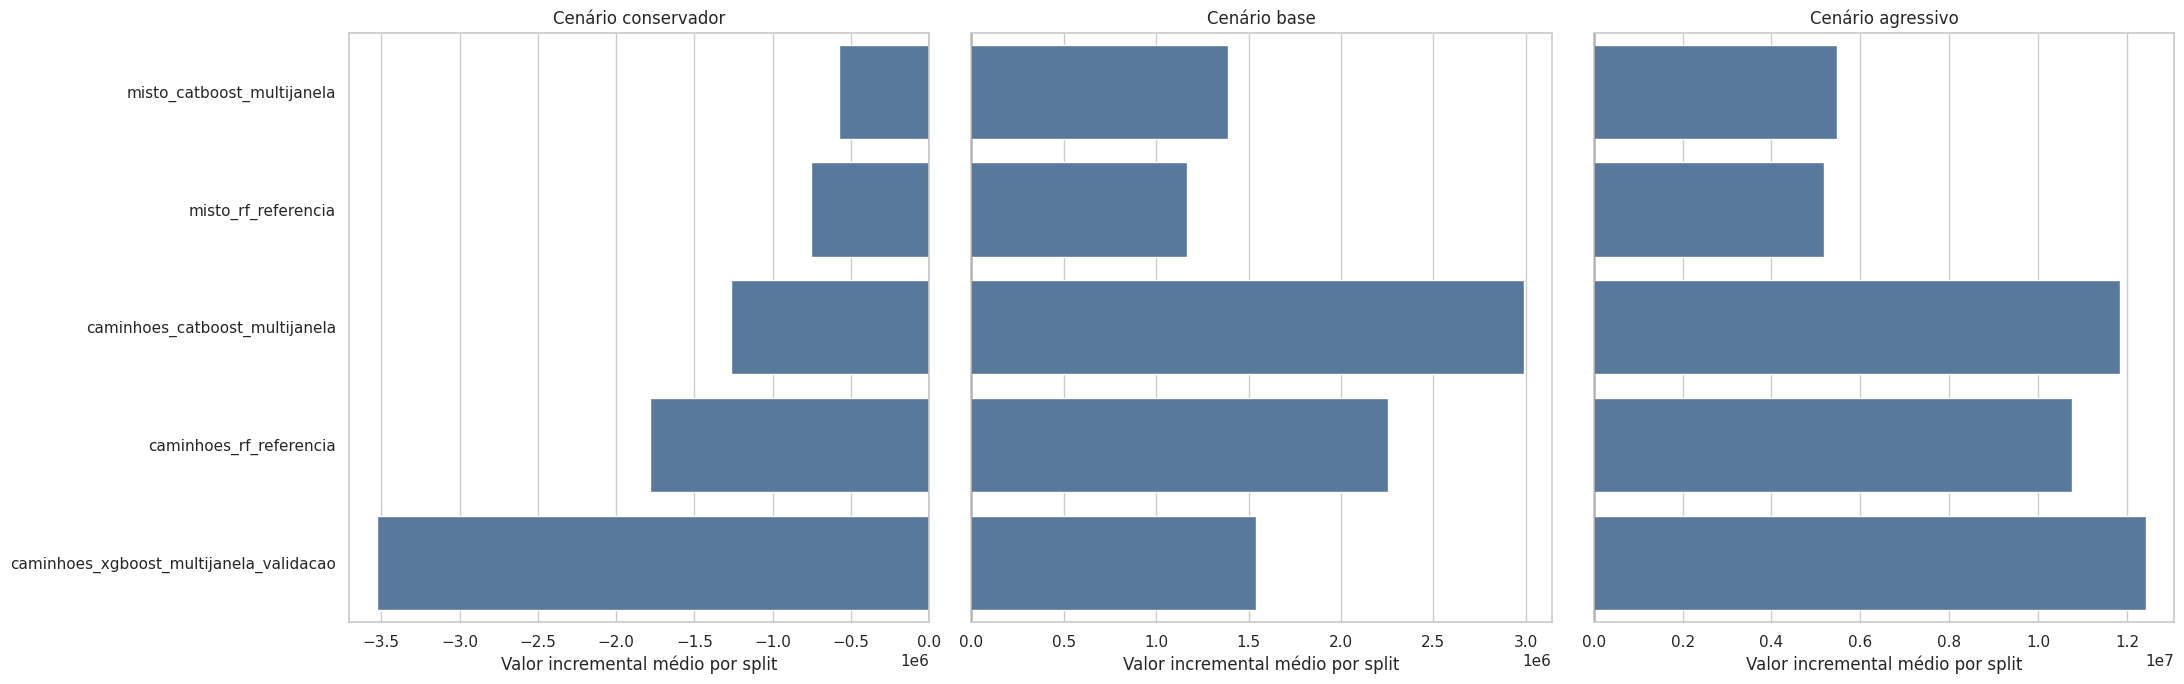

In [6]:
pivot_value = valuation_summary.pivot_table(
    index="politica",
    columns="cenario",
    values="valor_medio",
    aggfunc="mean",
).reset_index()
display(pivot_value)

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
for ax, scenario in zip(axes, ["conservador", "base", "agressivo"]):
    data = valuation_summary[valuation_summary["cenario"] == scenario].sort_values("valor_medio", ascending=False)
    sns.barplot(data=data, y="politica", x="valor_medio", ax=ax, color="#4C78A8")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Cenário {scenario}")
    ax.set_xlabel("Valor incremental médio por split")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Contribuição por Tipo

In [7]:
type_contribution = (
    valuation.groupby(["cenario", "politica", "Tipo"])
    .agg(
        valor_medio=("valor_incremental", "mean"),
        valor_total=("valor_incremental", "sum"),
        tp_total=("TP", "sum"),
        fp_total=("FP", "sum"),
        fn_total=("FN", "sum"),
    )
    .reset_index()
    .sort_values(["cenario", "valor_medio"], ascending=[True, False])
)
display(type_contribution)

,cenario,politica,Tipo,valor_medio,valor_total,tp_total,fp_total,fn_total
2,agressivo,caminhoes_xgboost_multijanela_validacao,Caminhao,1.243708e+07,37311250.0,291,479,635
0,agressivo,caminhoes_catboost_multijanela,Caminhao,1.184417e+07,35532500.0,218,221,708
3,agressivo,misto_catboost_multijanela,Caminhao,1.095292e+07,32858750.0,201,202,725
1,agressivo,caminhoes_rf_referencia,Caminhao,1.076333e+07,32290000.0,216,272,710
5,agressivo,misto_rf_referencia,Caminhao,1.036583e+07,31097500.0,202,238,724
4,agressivo,misto_catboost_multijanela,Escavadeira,0.000000e+00,0.0,0,0,10
6,agressivo,misto_rf_referencia,Escavadeira,0.000000e+00,0.0,0,0,10
7,base,caminhoes_catboost_multijanela,Caminhao,2.990200e+06,8970600.0,218,221,708
10,base,misto_catboost_multijanela,Caminhao,2.780567e+06,8341700.0,201,202,725
12,base,misto_rf_referencia,Caminhao,2.327800e+06,6983400.0,202,238,724


## 6. Leitura Auditada

In [8]:
best_by_scenario = valuation_summary.sort_values(["cenario", "valor_medio"], ascending=[True, False]).groupby("cenario").head(1)
display(best_by_scenario)

print("Conclusões:")
print("- No cenário conservador, políticas com muitos FP podem ficar negativas ou pouco atrativas.")
print("- No cenário base, o CatBoost caminhão-only tende a ser a política mais robusta entre as opções auditadas.")
print("- No cenário agressivo, modelos com maior recall ganham valor, mas o custo de FP ainda precisa ser controlado.")
print("- Escavadeiras não geram valor nos candidatos finais porque os modelos não acionam TP nesse tipo com o target atual.")
print("- Estes valores são simulação de cenário; ROI real exige custos internos, ordens de serviço e produção por frente/equipamento.")

,cenario,politica,modelo,escopo,threshold_ref,splits,valor_medio,valor_min,valor_max,valor_total_3_splits,tp_medio,fp_medio,fn_medio,precision_media,recall_media
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.243708e+07,10355000.0,15332500.0,37311250.0,97.000000,159.666667,211.666667,0.394754,0.313344
5,base,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,2.990200e+06,2433900.0,3307100.0,8970600.0,72.666667,73.666667,236.000000,0.505700,0.234775
13,conservador,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,-5.745000e+05,-1689000.0,0.0,-3447000.0,33.500000,33.666667,122.500000,0.515322,0.107449


Conclusões:
- No cenário conservador, políticas com muitos FP podem ficar negativas ou pouco atrativas.
- No cenário base, o CatBoost caminhão-only tende a ser a política mais robusta entre as opções auditadas.
- No cenário agressivo, modelos com maior recall ganham valor, mas o custo de FP ainda precisa ser controlado.
- Escavadeiras não geram valor nos candidatos finais porque os modelos não acionam TP nesse tipo com o target atual.
- Estes valores são simulação de cenário; ROI real exige custos internos, ordens de serviço e produção por frente/equipamento.
